In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
DATA_PATH = "E:/ML/UBC"

In [4]:
with open(os.path.join(DATA_PATH,"./FeatureDataSeg.pkl"), "rb") as f:
    zippedData = pickle.load(f)
    X,y, tma = zip(*zippedData)

In [7]:
minImCount = np.min([len(x) for x in X])

X = [x[0:minImCount] for x in X]

In [8]:
X = np.array(X)
X = np.max(X,1)
y = np.array(y)
print(X.shape)
print(y.shape)

(152, 512)
(152,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train.shape

(106,)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier().fit(X_train, y_train)
clf.score(X_train, y_train)

1.0

In [11]:
clf.score(X_test, y_test)

1.0

In [12]:
with open(os.path.join(DATA_PATH,"./FeatureClassifierSeg.pkl"), "wb") as f:
    pickle.dump(clf, f)

## t-SNE

In [22]:
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=2, perplexity=20).fit_transform(X)
print(X_embedded.shape)

(152, 2)


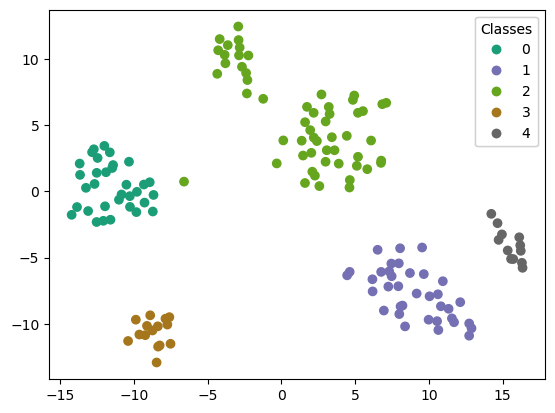

In [23]:
fig, ax = plt.subplots()

scatter = ax.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap="Dark2")

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)

# plt.colorbar()

## Test Other Classifiers

In [15]:
from sklearn.neighbors import KNeighborsClassifier

clfNN = KNeighborsClassifier(n_neighbors=6)

clfNN.fit(X_train,y_train)
print("Nearest Neighbors")
print(f"Train Score: {clfNN.score(X_train,y_train)}")
print(f"Test Score: {clfNN.score(X_test,y_test)}")


Nearest Neighbors
Train Score: 0.9905660377358491
Test Score: 0.9782608695652174


In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clfLDA = LinearDiscriminantAnalysis()

clfLDA.fit(X_train,y_train)
print("LDA")
print(f"Train Score: {clfLDA.score(X_train,y_train)}")
print(f"Test Score: {clfLDA.score(X_test,y_test)}")


LDA
Train Score: 1.0
Test Score: 0.9782608695652174


In [17]:
from sklearn.svm import SVC
clfSVM = SVC()

clfSVM.fit(X_train,y_train)
print("SVM")
print(f"Train Score: {clfSVM.score(X_train,y_train)}")
print(f"Test Score: {clfSVM.score(X_test,y_test)}")


SVM
Train Score: 1.0
Test Score: 1.0


In [16]:
with open(os.path.join(DATA_PATH,"./FeatureClassifierSVMEdgeTMA.pkl"), "wb") as f:
    pickle.dump(clfSVM, f)

## Novelty Detection

**Outlier detection**:


The training data contains outliers which are defined as observations that are far from the others. Outlier detection estimators thus try to fit the regions where the training data is the most concentrated, ignoring the deviant observations.

**Novelty detection**


The training data is not polluted by outliers and we are interested in detecting whether a **new** observation is an outlier. In this context an outlier is also called a novelty.

In [13]:
from sklearn.svm import OneClassSVM

clfOD = OneClassSVM(nu=0.1).fit(X)
print(clfOD.predict(X_test))

[ 1  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1 -1  1  1  1  1 -1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1 -1  1]


In [14]:
from sklearn.ensemble import IsolationForest

clfIF = IsolationForest().fit(X)
print(clfIF.predict(X_test))

[ 1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1]


In [15]:
with open(os.path.join(DATA_PATH,"./NoveltyDetector.pkl"), "wb") as f:
    pickle.dump(clfIF, f)

In [16]:
import sklearn
sklearn.__version__

'1.2.2'